# GKP State Preparation via GRAPE

Optimal control synthesis of a pulse that prepares a finite-energy GKP $\ket{0_L}$ state from vacuum in a single Kerr-nonlinear cavity driven by two-photon (squeezing) controls. The optimization uses gradient ascent in the Fourier domain with soft Lagrange-multiplier penalties enforcing amplitude limits, smoothness, and zero-amplitude boundaries.

## Imports

In [42]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from gkp_optimal_control.grape import (
    System,
    TimeGrid,
    FourierBand,
    Penalties,
    run_grape,
    save_pulse,
    forward_evolve
)
from gkp_optimal_control.hamiltonians import (
    kerr_cavity_drift,
    kerr_cavity_squeezing_controls,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import fock_state, gkp_states, cat_states
from gkp_optimal_control.utils import wigner_trajectory
from gkp_optimal_control.animation import animate_wigner

set_plot_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Target state

The target is the finite-energy logical $\ket{0_L}$ for a square-lattice GKP code with primitive displacements $\alpha = \sqrt{\pi/2}$ and $\beta = i\sqrt{\pi/2}$. The envelope width $\Delta$ sets the effective squeezing; the Fock-space truncation must accommodate the full support of the state.

In [79]:
n_fock = 100
gkp_delta = 0.3
gkp_cutoff = 10
gkp_alpha = jnp.sqrt(np.pi / 2)
gkp_beta = jnp.sqrt(np.pi / 2) * 1j

vac = fock_state(n_fock, 0)
gkp_0, gkp_1 = gkp_states(n_fock, gkp_alpha, gkp_beta, gkp_delta, gkp_cutoff)
even_cat, _ = cat_states(n_fock, gkp_alpha)

psi_init = vac.astype(jnp.complex128)
psi_targ = gkp_0.astype(jnp.complex128)

tail_population = float(jnp.sum(jnp.abs(psi_targ[-10:]) ** 2))
print(f"Target tail population (top 10 Fock levels): {tail_population:.2e}")

Target tail population (top 10 Fock levels): 5.97e-07


## System Hamiltonian

Single Kerr-nonlinear cavity in the rotating frame:
$$H/\hbar = \frac{K}{2} \hat{a}^\dagger \hat{a}^\dagger \hat{a} \hat{a} + \epsilon_I(t)\,(a^2 + a^{\dagger 2}) + i\,\epsilon_Q(t)\,(a^2 - a^{\dagger 2}).$$

The two control fields are the in-phase and quadrature components of a two-photon (squeezing) drive. Frequencies are stored as angular rates ($2\pi \times \text{MHz} = \text{rad}/\mu s$) and times in microseconds.

In [119]:
K = 2 * jnp.pi * (0.001)  # Kerr nonlinearity, rad/μs

h_drift    = kerr_cavity_drift(n_fock, kerr=K)
h_controls = kerr_cavity_squeezing_controls(n_fock)  # (2, dim, dim)

system = System(
    H_drift=h_drift,
    H_controls=h_controls,
    psi_init=psi_init,
    psi_targ=psi_targ,
)

## Optimization configuration

The pulse is parametrized in the Fourier domain with a hard frequency cutoff at $f_{\max}$. Soft penalties enforce amplitude limit $\epsilon_{\max}$, smoothness (squared-derivative), and zero amplitude in the first/last `boundary_n_zero` samples.

In [121]:
time_grid = TimeGrid(T=2.0, n_steps=500)  # 1.0 μs total, dt = 2 ns

band = FourierBand(f_max=100.0)  # MHz

penalties = Penalties(
    amp=0.1,
    deriv=1e-3,
    boundary=1.0,
    eps_max=10.0,
    boundary_n_zero=3,
)

## Run GRAPE

L-BFGS-B with analytic gradients via JAX autodiff. The first call pays a one-time JIT compilation cost; subsequent calls reuse the compiled cost-and-gradient function.

In [128]:
result, diag, params_to_pulse = run_grape(
    system,
    time_grid,
    band,
    penalties,
    seed=18,
    init_scale=0.01,
    maxiter=500,
)

 iter          loss         F      |grad|   elapsed
-------------------------------------------------------
   10     -0.559790   0.57012   1.345e+00     16.4s
   20     -0.568048   0.57104   1.052e+00     32.5s
   30     -0.569968   0.57124   3.697e-01     49.4s
   40     -0.570711   0.57142   2.245e-01     64.3s
   50     -0.571085   0.57154   4.866e-02     80.4s
   60     -0.571174   0.57160   5.790e-02     94.1s
   70     -0.571430   0.57170   1.203e-01    109.8s
   80     -0.571558   0.57179   1.148e-01    125.5s
   90     -0.571678   0.57190   3.876e-02    139.9s
  100     -0.571825   0.57201   7.182e-02    153.7s
  110     -0.571890   0.57212   4.385e-02    168.2s
  120     -0.571955   0.57218   3.016e-02    182.1s
  130     -0.572017   0.57223   8.364e-02    196.3s
  140     -0.572112   0.57239   5.943e-02    210.9s
  150     -0.572145   0.57242   6.075e-02    225.4s
  160     -0.572196   0.57248   2.232e-02    239.6s
  170     -0.572253   0.57247   2.545e-02    256.1s
  180   

In [123]:
# Multi-seed sweep
fidelities = []
for s in range(5):
    print(f"seed={s}")
    result, diag, _ = run_grape(
        system, time_grid, band, penalties,
        seed=s, init_scale=0.001, maxiter=200, verbose=True,
    )
    fidelities.append(diag['F'])
    print(f"  F = {diag['F']:.4f}")

print(f"\nFidelity range: {min(fidelities):.4f} - {max(fidelities):.4f}")

# Truncation check on the best run
best_seed = int(np.argmax(fidelities))
result, diag, _ = run_grape(
    system, time_grid, band, penalties,
    seed=best_seed, init_scale=0.001, maxiter=500, verbose=False,
)
pulse_jax = jnp.asarray(diag['pulse'])
_, traj = forward_evolve(
    pulse_jax, dt=time_grid.dt, psi_0=system.psi_init,
    h_drift=system.H_drift, h_controls=system.H_controls,
    return_history=True,
)
tail_pops = jnp.sum(jnp.abs(traj[:, -10:]) ** 2, axis=-1)
print(f"\nMax trajectory tail population: {float(jnp.max(tail_pops)):.2e}")

seed=0
 iter          loss         F      |grad|   elapsed
-------------------------------------------------------
   10     -0.570532   0.57089   2.726e-01     16.0s
   20     -0.570917   0.57111   2.270e-01     30.6s
   30     -0.571141   0.57125   9.211e-02     48.5s
   40     -0.571364   0.57153   3.691e-02     62.3s
   50     -0.571638   0.57189   8.239e-02     75.8s
   60     -0.571775   0.57200   4.888e-02     91.1s
   70     -0.571919   0.57214   1.366e-01    104.1s
   80     -0.572056   0.57229   6.429e-02    116.9s
   90     -0.572143   0.57239   8.072e-02    130.8s
  100     -0.572223   0.57246   8.897e-02    145.6s
  110     -0.572281   0.57249   3.516e-02    158.2s
  120     -0.572319   0.57254   3.825e-02    170.6s
  130     -0.572342   0.57252   5.821e-02    182.9s
  140     -0.572352   0.57253   1.825e-02    196.4s
  150     -0.572371   0.57254   3.957e-02    208.7s
  160     -0.572388   0.57256   1.966e-02    222.3s
  170     -0.572410   0.57259   2.443e-02    235.6s
 

KeyboardInterrupt: 

## Optimized pulse waveforms

Time-domain in-phase (I) and quadrature (Q) components of the two-photon drive, with the amplitude bound shown as a horizontal reference.

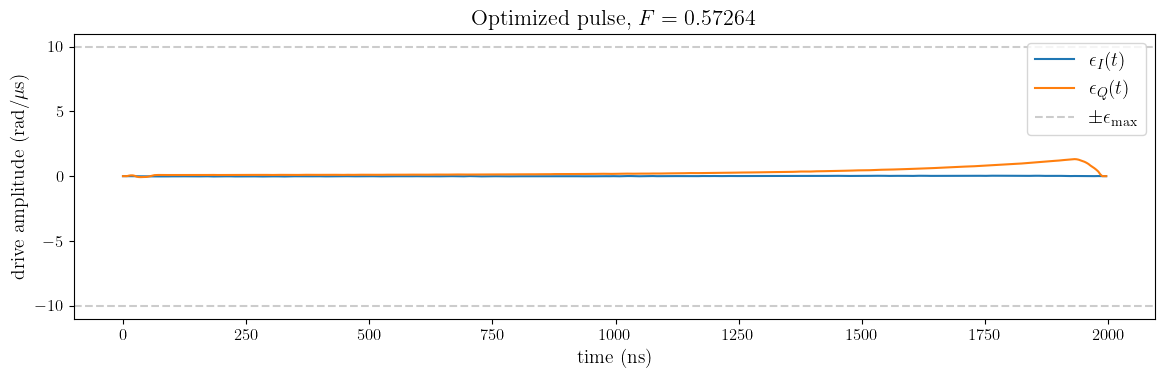

In [124]:
pulse = diag['pulse']
times_ns = np.arange(time_grid.n_steps) * time_grid.dt * 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times_ns, pulse[0], label=r'$\epsilon_I(t)$')
ax.plot(times_ns, pulse[1], label=r'$\epsilon_Q(t)$')
ax.axhline(+penalties.eps_max, color='gray', linestyle='--', alpha=0.4, label=r'$\pm\epsilon_{\max}$')
ax.axhline(-penalties.eps_max, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('time (ns)')
ax.set_ylabel(r'drive amplitude (rad/$\mu$s)')
ax.set_title(rf'Optimized pulse, $F = {diag["F"]:.5f}$')
ax.legend()
fig.tight_layout()
plt.show()

## Pulse spectrum

Frequency content of the optimized pulse. The hard cutoff at $f_{\max}$ is enforced by construction in the Fourier parametrization, not by a penalty.

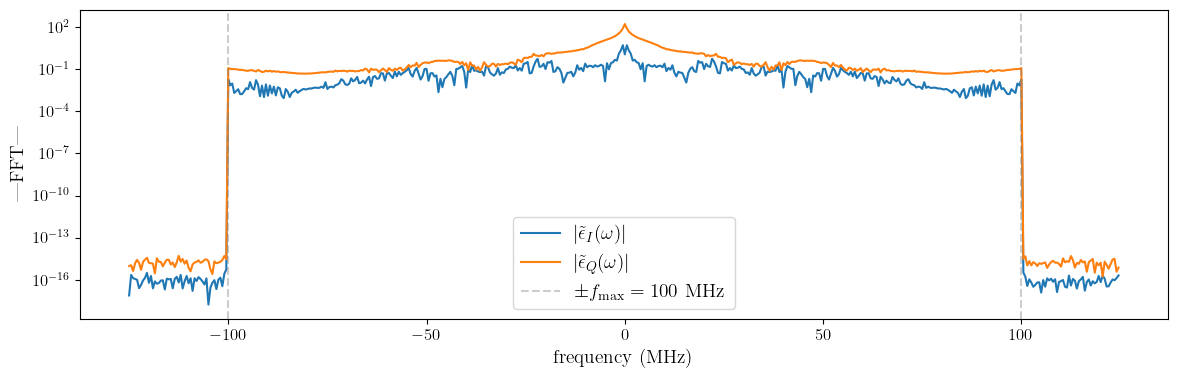

In [125]:
freqs = np.fft.fftshift(np.fft.fftfreq(time_grid.n_steps, d=time_grid.dt))
spectra = np.abs(np.fft.fftshift(np.fft.fft(pulse, axis=-1), axes=-1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs, spectra[0], label=r'$|\tilde\epsilon_I(\omega)|$')
ax.plot(freqs, spectra[1], label=r'$|\tilde\epsilon_Q(\omega)|$')
ax.axvline(+band.f_max, color='gray', linestyle='--', alpha=0.4, label=rf'$\pm f_{{\max}} = {band.f_max:g}$ MHz')
ax.axvline(-band.f_max, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel('frequency (MHz)')
ax.set_ylabel('|FFT|')
ax.set_yscale('log')
ax.legend()
fig.tight_layout()
plt.show()

## Final state vs. target

Wigner functions of the achieved final state and the target $\ket{0_L}$. A successful encoding reproduces the target's characteristic GKP lattice of positive and negative peaks.

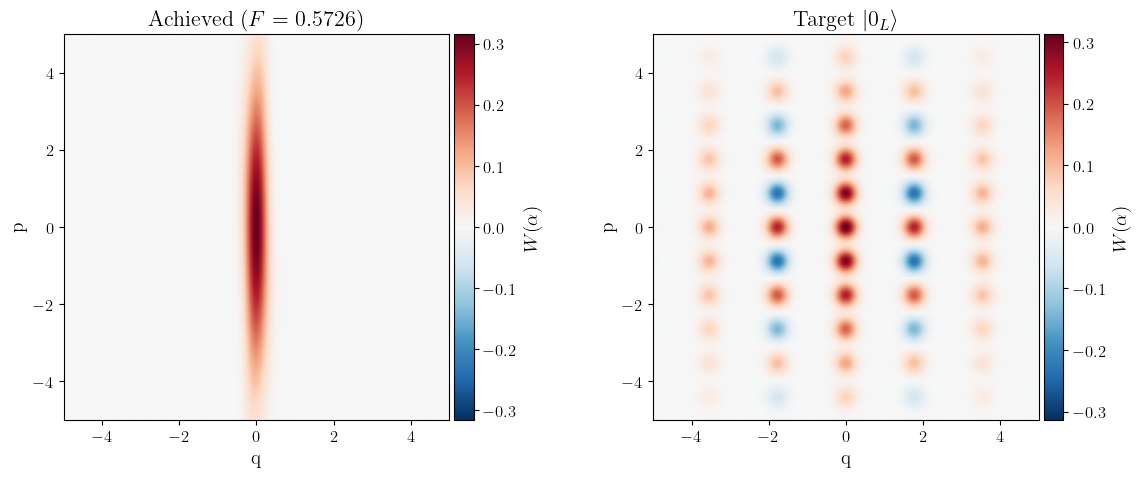

In [126]:
psi_final = jnp.asarray(diag['psi_final'])
psi_final = psi_final / jnp.linalg.norm(psi_final)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_wigner(psi_final, x_bound=5, y_bound=5, ax=axes[0],
            title=rf'Achieved ($F = {diag["F"]:.4f}$)')
plot_wigner(psi_targ, x_bound=5, y_bound=5, ax=axes[1],
            title=r'Target $\ket{0_L}$')
fig.tight_layout()
plt.show()

In [115]:
# Get the trajectory and inspect max Fock occupation over time.
pulse_jax = jnp.asarray(diag['pulse'])
psi_f, traj = forward_evolve(
    pulse_jax, dt=time_grid.dt, psi_0=system.psi_init,
    h_drift=system.H_drift, h_controls=system.H_controls,
    return_history=True,
)
# Max tail population over the whole trajectory.
tail_pops = jnp.sum(jnp.abs(traj[:, -10:]) ** 2, axis=-1)
print(f"max trajectory tail population: {float(jnp.max(tail_pops)):.2e}")

max trajectory tail population: 5.67e-29


CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1600x1200', '-pix_fmt', 'rgba', '-framerate', '25', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-preset', 'fast', '-crf', '18', '-y', '../../vids/grape/vac_to_gkp_0_2.mp4']' returned non-zero exit status 255.

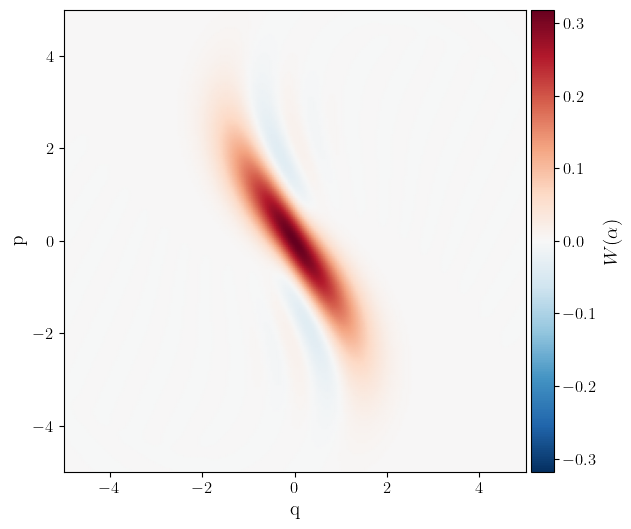

In [116]:
# Re-run the forward evolution, this time recording every intermediate state.
pulse_jax = jnp.asarray(diag['pulse'])
psi_f, traj = forward_evolve(
    pulse_jax,
    dt=time_grid.dt,
    psi_0=system.psi_init,
    h_drift=system.H_drift,
    h_controls=system.H_controls,
    return_history=True,
)
# traj has shape (n_steps, dim) -- one ket per slice.

# Wigner functions along the trajectory.
xvec, yvec, frames = wigner_trajectory(
    traj, x_bound=5.0, y_bound=5.0, grid_points=200,
)

# Render an animation.
animate_wigner(
    frames, xvec, yvec,
    # title=r'GRAPE trajectory $|0\rangle \to |0_L\rangle$',
    save_path='../../vids/grape/vac_to_gkp_0_2.mp4',
    dpi=200,
)

## Photon-number distributions

Diagonal of the density matrix in the Fock basis. The achieved distribution should track the target. Significant population near $n = n_{\text{fock}}$ would indicate the truncation is too tight.

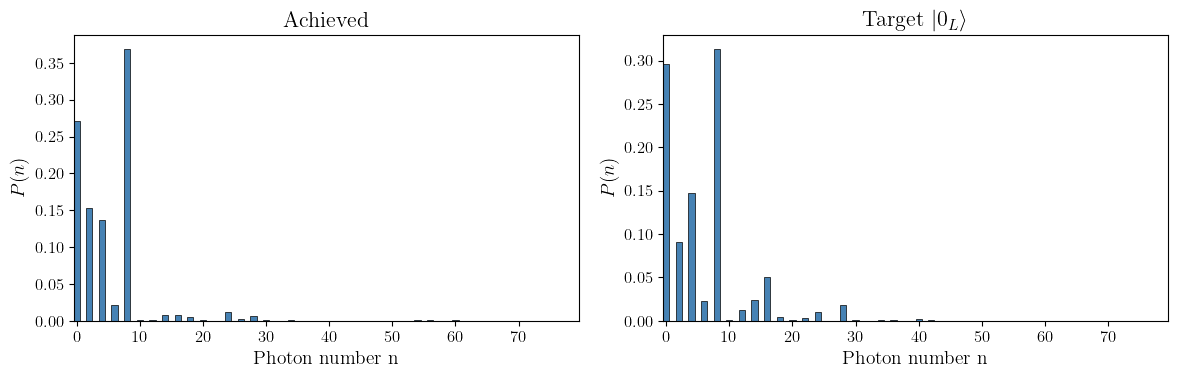

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_photon_number(psi_final, ax=axes[0], title='Achieved')
plot_photon_number(gkp_0, ax=axes[1], title=r'Target $\ket{0_L}$')
fig.tight_layout()
plt.show()

## Save the pulse

Persist the optimized pulse along with the parameters needed to reconstruct it on hardware (or in a follow-up notebook).

In [ ]:
save_pulse(
    'gkp_state_prep.npz',
    pulse,
    metadata={
        'fidelity': diag['F'],
        'T_us': time_grid.T,
        'n_steps': time_grid.n_steps,
        'f_max_MHz': band.f_max,
        'eps_max': penalties.eps_max,
        'n_fock': n_fock,
        'gkp_delta': gkp_delta,
        'K_rad_per_us': float(K),
    },
)